In [1]:
import requests
import json
import pandas as pd
import _utils_ as utils
import _connection_ as con

Variables

In [2]:
city = 'Bogota'
gbfs_url='https://bogota.publicbikesystem.net/customer/gbfs/v2/gbfs.json'

In [3]:
all_data_links = requests.get(gbfs_url).json()
feeds_dict = {feed['name']: feed['url'] for feed in all_data_links['data']['en']['feeds']}
all_data_links

{'last_updated': 1780017583,
 'ttl': 30,
 'data': {'en': {'feeds': [{'name': 'geofencing_zones',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/geofencing_zones'},
    {'name': 'gbfs_versions',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/gbfs_versions'},
    {'name': 'vehicle_types',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/vehicle_types'},
    {'name': 'station_information',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/station_information'},
    {'name': 'station_status',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/station_status'},
    {'name': 'system_regions',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/system_regions'},
    {'name': 'system_information',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/system_information'},
    {'name': 'system_pricing_plans',
     'url': 'https://bogota.publicbikesystem.net/customer/

## 1 - Exploracion de Datos

### 1.1 Informacion general del sistema

In [4]:
geofencing_zones  = requests.get(feeds_dict['geofencing_zones']).json()
system_regions  = requests.get(feeds_dict['system_regions']).json()
system_information  = requests.get(feeds_dict['system_information']).json()
gbfs_versions = requests.get(feeds_dict['gbfs_versions']).json()
print("geofencing_zones\n", geofencing_zones['data'])
print("\nsystem_regions\n", system_regions['data'])
print("\nsystem_information\n", system_information['data'])
print("\ngbfs_versions\n",  gbfs_versions['data'])

geofencing_zones
 {'geofencing_zones': {'features': [], 'type': 'FeatureCollection'}}

system_regions
 {'regions': []}

system_information
 {'system_id': 'bogota_bike', 'timezone': 'America/Bogota', 'build_version': '2026.2', 'build_label': '2026-05-08', 'build_hash': '2c93a26', 'build_number': '30', 'mobile_head_version': '2', 'mobile_minimum_supported_version': '1', '_vehicle_count': {'_mechanical_count': 1942, '_ebike_count': 1556}, '_station_count': 192, 'language': 'en', 'name': 'bogota-bikebogota'}

gbfs_versions
 {'versions': [{'version': '1.1', 'url': 'https://bogota.publicbikesystem.net/ube/gbfs/v1/'}, {'version': '2.3', 'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/'}, {'version': '3.0', 'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v3.0/'}]}


### 1.2. Precios de planes y tipos de vehiculos

In [5]:
# system_pricing_plans
system_pricing_plans = requests.get(feeds_dict['system_pricing_plans']).json()
for plan in system_pricing_plans['data']['plans'][0:5]:
    print(plan)


{'plan_id': '1', 'name': 'Teste 06.09', 'currency': 'COP', 'price': 9000.0, 'description': 'Teste 06.09', 'is_taxable': True, 'per_min_pricing': [{'start': 0, 'rate': 7500.0, 'interval': 30, 'end': 30}]}
{'plan_id': '2-2', 'name': 'Diario', 'currency': 'COP', 'price': 11000.0, 'description': 'Diario', 'is_taxable': True, 'per_min_pricing': [{'start': 65, 'rate': 150.0, 'interval': 1, 'end': 2465}]}
{'plan_id': '2-3', 'name': 'Diario', 'currency': 'COP', 'price': 11000.0, 'description': 'Diario', 'is_taxable': True, 'per_min_pricing': [{'start': 0, 'rate': 1999.0, 'interval': 1, 'end': 1}, {'start': 1, 'rate': 150.0, 'interval': 1, 'end': 2387}]}
{'plan_id': '3-5', 'name': '[Set.22] Mensual', 'currency': 'COP', 'price': 31990.0, 'description': '[Set.22] Mensual', 'is_taxable': True, 'per_min_pricing': [{'start': 60, 'rate': 150.0, 'interval': 1, 'end': 2460}]}
{'plan_id': '3-4', 'name': '[Set.22] Mensual', 'currency': 'COP', 'price': 31990.0, 'description': '[Set.22] Mensual', 'is_taxab

In [6]:
#vehicle_types
vehicle_types = requests.get(feeds_dict['vehicle_types']).json()
pd.DataFrame(vehicle_types['data']['vehicle_types']).head(7)

,vehicle_type_id,form_factor,propulsion_type,max_range_meters,name,default_pricing_plan_id,pricing_plan_ids
0,ICONIC,bicycle,human,0.0,ICONIC,1,"[1, 2-2, 2-3, 3-5, 3-4, 4-6, 4-7, 5, 6-9, 6-10..."
1,FIT,bicycle,human,0.0,FIT,1,"[1, 2-2, 2-3, 3-5, 3-4, 4-6, 4-7, 5, 6-9, 6-10..."
2,BOOST,bicycle,electric_assist,70000.0,BOOST,1,"[1, 2-2, 2-3, 3-5, 3-4, 4-6, 4-7, 5, 6-9, 6-10..."
3,EFIT,bicycle,electric_assist,70000.0,EFIT,1,"[1, 2-2, 2-3, 3-5, 3-4, 4-6, 4-7, 5, 6-9, 6-10..."
4,MANOCLETA,other,human,0.0,MANOCLETA,3-5,"[3-5, 3-4, 8-9, 8-46, 11-12, 11-17, 12-2, 12-3..."
5,CAJON,bicycle,human,0.0,CAJON,3-5,"[3-5, 3-4, 8-9, 8-46, 11-12, 11-17, 12-2, 12-3..."
6,FIT CON SILLA,bicycle,human,0.0,FIT CON SILLA,1,"[1, 2-2, 2-3, 3-5, 3-4, 4-6, 4-7, 5, 6-9, 6-10..."


### 1.3 Informacion de Estacion

In [7]:
station_information = requests.get(feeds_dict['station_information']).json()
print("numero de estaciones: ", len(station_information['data']['stations']))
print(station_information['data']['stations'][0])
station_information_df = pd.DataFrame(station_information['data']['stations'][0:-1])
station_information_df[-4:-1]

numero de estaciones:  194
{'station_id': '1', 'external_id': 'eb1564d9-df87-11ef-b9d3-0681a956ccf1', 'name': '001 - CL 82 con KR 11', 'physical_configuration': 'REGULAR', 'lat': 4.6658027, 'lon': -74.0528436, 'altitude': None, 'address': 'Calle 82 entre Carrera 11 y Carrera 12', 'cross_street': 'EL RETIRO', 'post_code': '1111', 'capacity': 19, 'is_charging_station': False, 'geofenced_capacity': 0, 'rental_methods': ['key', 'transitcard', 'creditcard', 'phone'], 'is_virtual_station': False, 'groups': [], 'nearby_distance': 1000.0, '_bluetooth_id': '7fb4', '_ride_code_support': True, 'rental_uris': {}}


,station_id,external_id,name,physical_configuration,lat,lon,altitude,address,cross_street,post_code,...,rental_methods,is_virtual_station,groups,nearby_distance,_bluetooth_id,_ride_code_support,rental_uris,obcn,short_name,is_valet_station
189,296,eb185b7e-df87-11ef-b9d3-0681a956ccf1,296 - KR 19A con CL 100,REGULAR,4.686673,-74.052952,None,Carrera 19A entre Calle 100 y Calle 101,NaN,1111,...,"[key, transitcard, creditcard, phone]",False,[],1000.0,fec5,True,{},,,NaN
190,298,eb185fd3-df87-11ef-b9d3-0681a956ccf1,298 - KR 23 con CL 104A,REGULAR,4.691679,-74.055155,None,Carrera 23 entre Calle 104A y Calle 104,NaN,1111,...,"[key, transitcard, creditcard, phone]",False,[],1000.0,2810,True,{},,,NaN
191,300,eb186741-df87-11ef-b9d3-0681a956ccf1,300 - KR 18A con CL 102,REGULAR,4.687820,-74.050715,None,Carrera 18A entre Calle 102 y Calle 103,NaN,1111,...,"[key, transitcard, creditcard, phone]",False,[],1000.0,7223,True,{},,,NaN


### 1.4 Estado de Estacion

In [8]:
station_status= requests.get(feeds_dict['station_status']).json()
print("numero de estaciones: ", len(station_status['data']['stations']))
print(list(station_status['data']['stations'][0].keys()))
print('vehicle_docks_available',station_status['data']['stations'][0]['vehicle_docks_available'])

print('vehicle_types_available')
for veh_type in station_status['data']['stations'][0]['vehicle_types_available']:
    print("  ",veh_type)
station_status_df = pd.DataFrame(station_status['data']['stations'])
station_status_df[0:4]

# station_status

numero de estaciones:  194
['station_id', 'num_bikes_available', 'num_bikes_disabled', 'is_charging_station', 'status', 'traffic', 'num_docks_available', 'num_docks_disabled', 'last_reported', 'is_installed', 'is_renting', 'is_returning', 'vehicle_docks_available', 'vehicle_types_available']
vehicle_docks_available [{'vehicle_type_ids': ['FIT', 'EFIT', 'CARGO', 'Handbike'], 'count': 19}]
vehicle_types_available
   {'vehicle_type_id': 'FIT', 'count': 0}
   {'vehicle_type_id': 'CARGO', 'count': 0}
   {'vehicle_type_id': 'Handbike', 'count': 0}
   {'vehicle_type_id': 'EFIT', 'count': 0}


,station_id,num_bikes_available,num_bikes_disabled,is_charging_station,status,traffic,num_docks_available,num_docks_disabled,last_reported,is_installed,is_renting,is_returning,vehicle_docks_available,vehicle_types_available
0,1,0,0,False,IN_SERVICE,None,19,0,1780017520,True,True,True,"[{'vehicle_type_ids': ['FIT', 'EFIT', 'CARGO',...","[{'vehicle_type_id': 'FIT', 'count': 0}, {'veh..."
1,2,3,1,False,IN_SERVICE,None,3,0,1780017406,True,True,True,"[{'vehicle_type_ids': ['FIT', 'EFIT', 'CARGO',...","[{'vehicle_type_id': 'FIT', 'count': 2}, {'veh..."
2,4,2,0,False,IN_SERVICE,None,9,0,1780017445,True,True,True,"[{'vehicle_type_ids': ['FIT', 'EFIT', 'CARGO',...","[{'vehicle_type_id': 'FIT', 'count': 2}, {'veh..."
3,5,15,2,False,IN_SERVICE,None,23,0,1780017539,True,True,True,"[{'vehicle_type_ids': ['FIT', 'EFIT', 'CARGO',...","[{'vehicle_type_id': 'FIT', 'count': 13}, {'ve..."


## 2 - Visualizacion de Informacion

In [14]:
# station_information_df.sort_values(by=['lat', 'lon'], ascending=[True, True]).head(10)
#found an edge case with lat <0 when all other lats are ~4.6. Adding condition to filter out that station
station_information_df = station_information_df[station_information_df['lat'] > 0]

<Figure size 800x800 with 0 Axes>

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


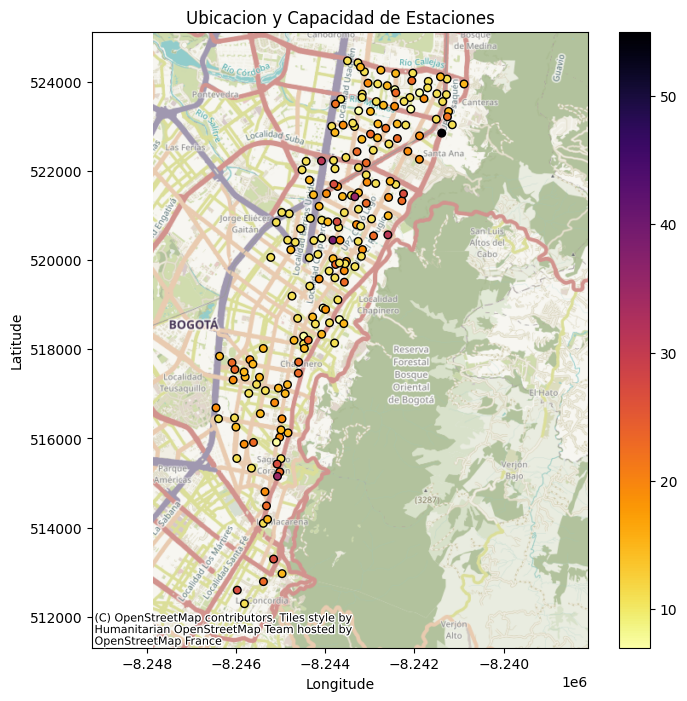

In [15]:
utils.plot_map(station_information_df, 'capacity', 'inferno_r', 'Ubicacion y Capacidad de Estaciones')

<Figure size 800x800 with 0 Axes>

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


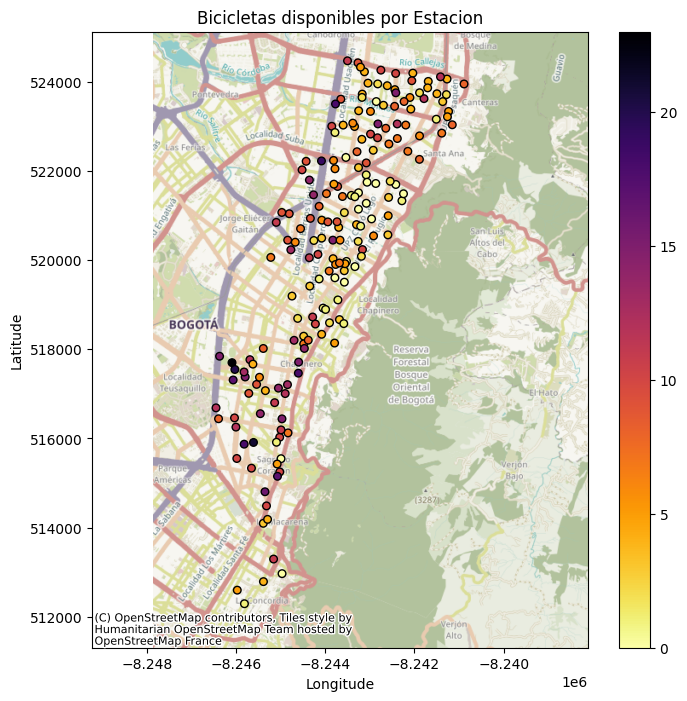

In [16]:
station_info_status_df = station_information_df.merge(station_status_df, on='station_id')
utils.plot_map(station_info_status_df, 'num_bikes_available', 'inferno_r', 'Bicicletas disponibles por Estacion')

<Figure size 800x800 with 0 Axes>

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


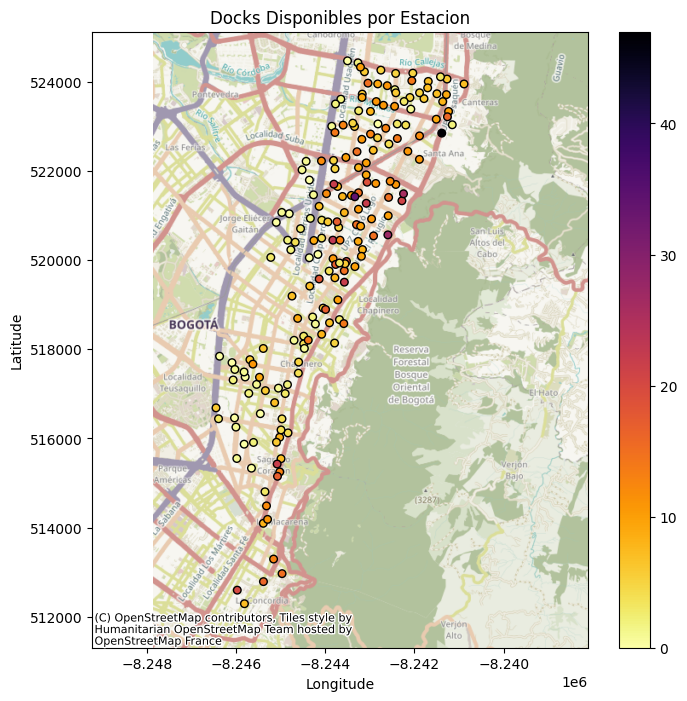

In [17]:
utils.plot_map(station_info_status_df, 'num_docks_available', 'inferno_r', 'Docks Disponibles por Estacion')

In [23]:
station_information_df.shape

(192, 23)

------- Seleccionar un subset de estaciones para alamacenamiento y analitica

In [31]:
station_info_df = station_information_df.sort_values(by="capacity", ascending=False)
station_info_df = utils.select_stations_far_apart(station_info_df, n=140, min_dist_m=700)


In [32]:
#### filtering and selecting stations by capacity, location, randomness


# 1. Select top N by capacity
top_capacity = station_info_df.nlargest(5, 'capacity')

# 2. Select stations with charging (if available)
charging_stations = station_info_df[station_info_df['is_charging_station'] == 1].sample(n=3, random_state=42)

# 3. Select geographical edges stations (e.g., by min/max lat)
geo_edges = station_info_df.loc[[
    station_info_df['lat'].idxmin(), station_info_df['lat'].idxmax(),
    station_info_df['lon'].idxmin(), station_info_df['lon'].idxmax()
]]

# 4. Add some random stations
remaining = station_info_df.drop(top_capacity.index).drop(charging_stations.index).drop(geo_edges.index)
random_stations = remaining.sample(n=3, random_state=42)


In [33]:
# Combine and drop duplicates
selected_stations = pd.concat([top_capacity, charging_stations, geo_edges, random_stations]).drop_duplicates(subset=['station_id']).sort_values(by='station_id')
selected_stations

,station_id,external_id,name,physical_configuration,lat,lon,altitude,address,cross_street,post_code,...,rental_methods,is_virtual_station,groups,nearby_distance,_bluetooth_id,_ride_code_support,rental_uris,obcn,short_name,is_valet_station
72,100,eb167403-df87-11ef-b9d3-0681a956ccf1,100 - CL 12A con KR 7,REGULAR,4.599807,-74.074831,None,Calle 12A entre Carrera 7 y Carrera 8,MICROZONA 1 (MURILLO),1111,...,"[key, transitcard, creditcard, phone]",False,[],1000.0,3441,True,{},,,NaN
79,108,eb16877a-df87-11ef-b9d3-0681a956ccf1,108 - KR 7 con CL 35,REGULAR,4.622666,-74.066732,None,Carrera 7 entre Calle 35 y Calle 36,SAGRADO CORAZON,1111,...,"[key, transitcard, creditcard, phone]",False,[],1000.0,bb0b,True,{},,,NaN
83,113,eb16923b-df87-11ef-b9d3-0681a956ccf1,113 - CL 22 con KR 4,REGULAR,4.606051,-74.067520,None,Calle 22 entre Carrera 3 y Carrera 4,LAS NIEVES,1111,...,"[key, transitcard, creditcard, phone]",False,[],1000.0,3d49,True,{},,,NaN
101,171,eb172034-df87-11ef-b9d3-0681a956ccf1,171 - CL 93B con KR 15,REGULAR,4.678780,-74.051150,None,Calle 93B entre Carrera 15 y Carrera 16,NaN,1111,...,"[key, transitcard, creditcard, phone]",False,[],1000.0,935f,True,{},,,NaN
115,194,eb175558-df87-11ef-b9d3-0681a956ccf1,194 - Auto Norte con CL 100,ELECTRICBIKESTATION,4.685971,-74.057875,None,Avenida Carrera 45 entre Calle 100 y Calle 97,NaN,1111,...,"[key, transitcard, creditcard, phone]",False,[],1000.0,f27b,True,{},,,NaN
122,202,eb176669-df87-11ef-b9d3-0681a956ccf1,202 - CL 126 con KR 7,REGULAR,4.701419,-74.029162,None,Calle 126A entre Carrera 7 y Carrera 7A,NaN,1111,...,"[key, transitcard, creditcard, phone]",False,[],1000.0,,True,{},KP220400078,KP220400078,NaN
127,210,eb1777a0-df87-11ef-b9d3-0681a956ccf1,210 - KR 49A con CL 85A,ELECTRICBIKESTATION,4.675632,-74.065863,None,Carrera 49A entre Calle 85A y Calle 86A,NaN,1111,...,"[key, transitcard, creditcard, phone]",False,[],1000.0,32a0,True,{},,,NaN
132,217,eb1786d8-df87-11ef-b9d3-0681a956ccf1,217 - KR 8A con CL 97A,REGULAR,4.679382,-74.041353,None,Carrera 8A entre Calle 97A y Calle 98,NaN,1111,...,"[key, transitcard, creditcard, phone]",False,[],1000.0,df04,True,{},,,NaN
138,224,eb179a0b-df87-11ef-b9d3-0681a956ccf1,224 - KR 13A con CL 107A,REGULAR,4.690471,-74.042596,None,Carrera 13A entre Calle 107A y Calle 108,NaN,1111,...,"[key, transitcard, creditcard, phone]",False,[],1000.0,dae9,True,{},,,NaN
145,234,eb17b12c-df87-11ef-b9d3-0681a956ccf1,234 - KR 13 con CL 125A,REGULAR,4.702071,-74.039678,None,Carrera 13 entre Calle 125A y Calle 123,NaN,1111,...,"[key, transitcard, creditcard, phone]",False,[],1000.0,e31d,True,{},,,NaN


<Figure size 800x800 with 0 Axes>

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


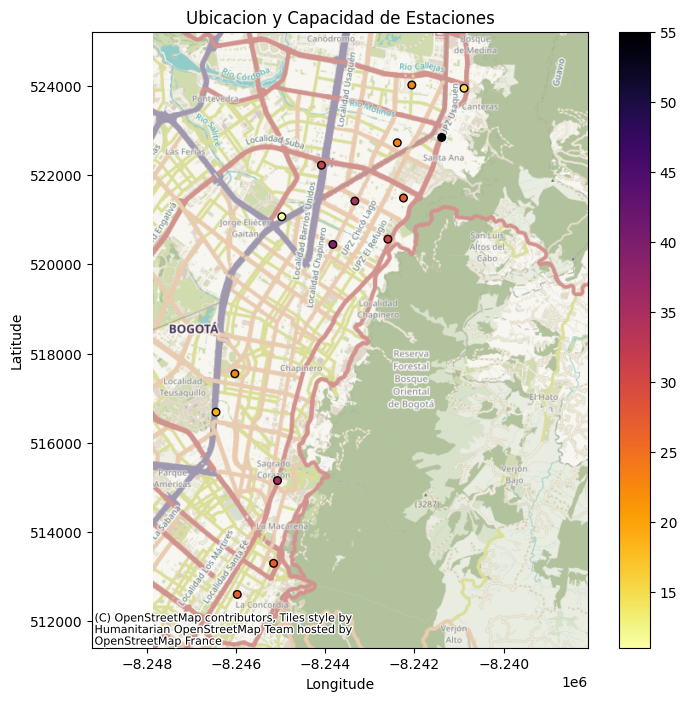

In [34]:
utils.plot_map(selected_stations, 'capacity', 'inferno_r', 'Ubicacion y Capacidad de Estaciones')

<Figure size 800x800 with 0 Axes>

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


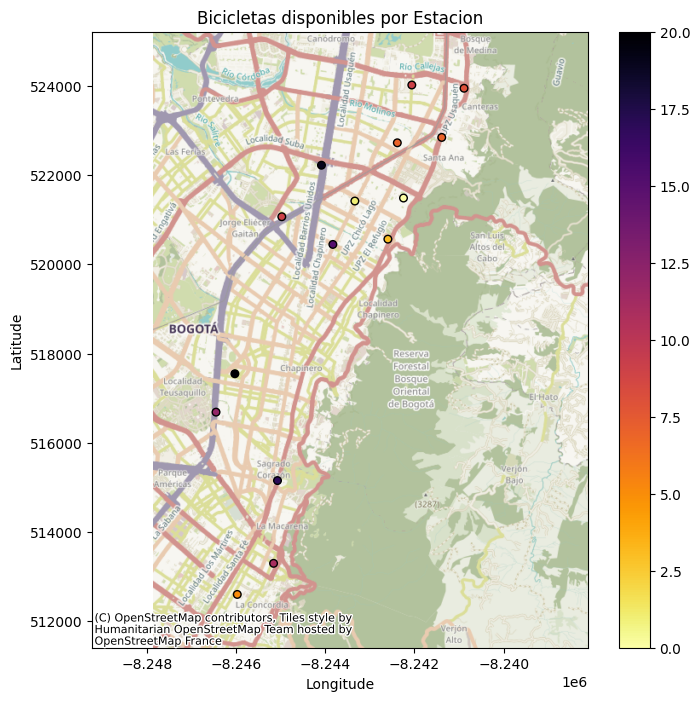

In [35]:
#Visualizar subsección de estaciones seleccionadas
station_info_status_sub_df = selected_stations.merge(station_status_df, on='station_id', how='left')
utils.plot_map(station_info_status_sub_df, 'num_bikes_available', 'inferno_r', 'Bicicletas disponibles por Estacion')

In [38]:
#save the selected stations to a csv file in the static_data_files folder
from datetime import datetime
today = datetime.now().strftime("%Y-%m-%d")
selected_stations.to_csv(f'static_data_files/selected_stations_{today}.csv', index=False)